<a href="https://colab.research.google.com/github/mohamadfaisalbashir/Practical-Linear-Algebra/blob/main/05_Matrices_Part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Matrices, Part 1**

This notebook covers Matrices, Part 1:
1. Creating and Visualizing Matrices in NumPy
2. Special Matrices
3. Matrix Math: Addition, Scalar Multiplication, Hadamard Multiplication
4. Standard Matrix Multiplication
5. Matrix Operations: Transpose
6. Symmetric Matrices
7. Code Exercises

## **1. Creating and Visualizing Matrices in NumPy**

A matrix is, in essence, a vector taken to the next level of abstraction and utility. Matrices are extraordinarily versatile mathematical objects that serve simultaneously as data tables, geometric transformation mechanisms, systems of equations, and structured collections of individual scalar values. In the context of data science specifically, a matrix is almost always referred to as a data table, where rows represent observations — such as individual customers, patients, or time points — and columns represent features or measured variables

Depending on context, matrices can be conceptualized in at least three distinct ways: as a horizontal stack of column vectors (useful for data tables), as a vertical stack of row vectors (useful for multi-sensor time series), or as an ordered grid of individual scalar values (useful for images). In practice, all three views refer to the same underlying object — and the appropriate conceptualization depends on the problem at hand.

Small matrices can simply be printed in full. However, for the large matrices routinely encountered in data science — which can contain millions or even billions of elements — visualization as a pseudocolored image is far more practical and informative. Each element maps to a color, and the resulting image often reveals structure, patterns, and anomalies that raw numbers would obscure.

### **1.1 Visualizing, Indexing, and Slicing Matrices**

Matrices are indexed using (row, column) convention — a convention shared between mathematics and Python, though with an important offset: mathematics uses 1-based indexing while Python uses 0-based indexing. Therefore, the element at mathematical position (3, 4) is accessed in Python as A[2, 3]. Extracting subsets of a matrix is done through slicing, where you specify inclusive start and exclusive end indices for both rows and columns.

In [1]:
import numpy as np

# Create a matrix and demonstrate indexing and slicing
A = np.arange(60).reshape(6, 10)
print('Original matrix:')
print(A)

# Extract submatrix: rows 2-4 (1-indexed), columns 1-5 (1-indexed)
# In Python (0-indexed): rows [1:4], columns [0:5]
sub = A[1:4:1, 0:5:1]
print('\nSubmatrix (rows 2-4, columns 1-5):')
print(sub)

Original matrix:
[[ 0  1  2  3  4  5  6  7  8  9]
 [10 11 12 13 14 15 16 17 18 19]
 [20 21 22 23 24 25 26 27 28 29]
 [30 31 32 33 34 35 36 37 38 39]
 [40 41 42 43 44 45 46 47 48 49]
 [50 51 52 53 54 55 56 57 58 59]]

Submatrix (rows 2-4, columns 1-5):
[[10 11 12 13 14]
 [20 21 22 23 24]
 [30 31 32 33 34]]


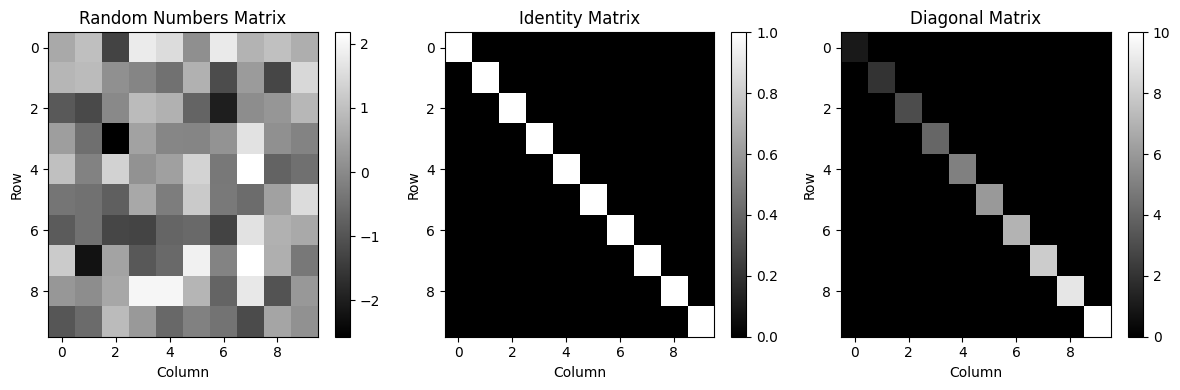

In [2]:
import matplotlib.pyplot as plt
# Visualize three different matrices as images
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Random numbers matrix
A_rand = np.random.randn(10, 10)
axes[0].imshow(A_rand, cmap='gray', aspect='auto')
axes[0].set_title('Random Numbers Matrix')
axes[0].set_xlabel('Column'); axes[0].set_ylabel('Row')
plt.colorbar(axes[0].images[0], ax=axes[0])

# Identity matrix
A_eye = np.eye(10)
axes[1].imshow(A_eye, cmap='gray', aspect='auto')
axes[1].set_title('Identity Matrix')
axes[1].set_xlabel('Column'); axes[1].set_ylabel('Row')
plt.colorbar(axes[1].images[0], ax=axes[1])

# Diagonal matrix
A_diag = np.diag(np.arange(1, 11))
axes[2].imshow(A_diag, cmap='gray', aspect='auto')
axes[2].set_title('Diagonal Matrix')
axes[2].set_xlabel('Column'); axes[2].set_ylabel('Row')
plt.colorbar(axes[2].images[0], ax=axes[2])

plt.tight_layout()
plt.show()

## **2. Special Matrices**

Although there is technically an infinite variety of possible matrices, they can be usefully categorized into a relatively small number of families based on their structural properties. These families matter immensely in practice: certain operations are defined only for certain families (e.g., the trace requires a square matrix), and certain families have special mathematical properties that simplify algorithms enormously (e.g., diagonal matrices have trivially simple inverses).

The most important special matrix types to know for data science are:

- **Random numbers matrix** — drawn from a distribution (typically Gaussian); invaluable for exploring linear algebra numerically.
- **Square vs. nonsquare** — a square matrix has equal rows and columns (ℝ^{N×N}). Nonsquare matrices are called *tall* (more rows than columns) or *wide* (more columns than rows).
- **Diagonal** — only the main diagonal (top-left to bottom-right) may contain nonzero values.
- **Triangular** — either the upper or lower triangle is all zeros. NumPy provides `np.triu()` and `np.tril()` for extraction.
- **Identity** — the matrix equivalent of the scalar 1; multiplying any matrix by the identity leaves it unchanged.
- **Zeros** — the matrix equivalent of the scalar 0.

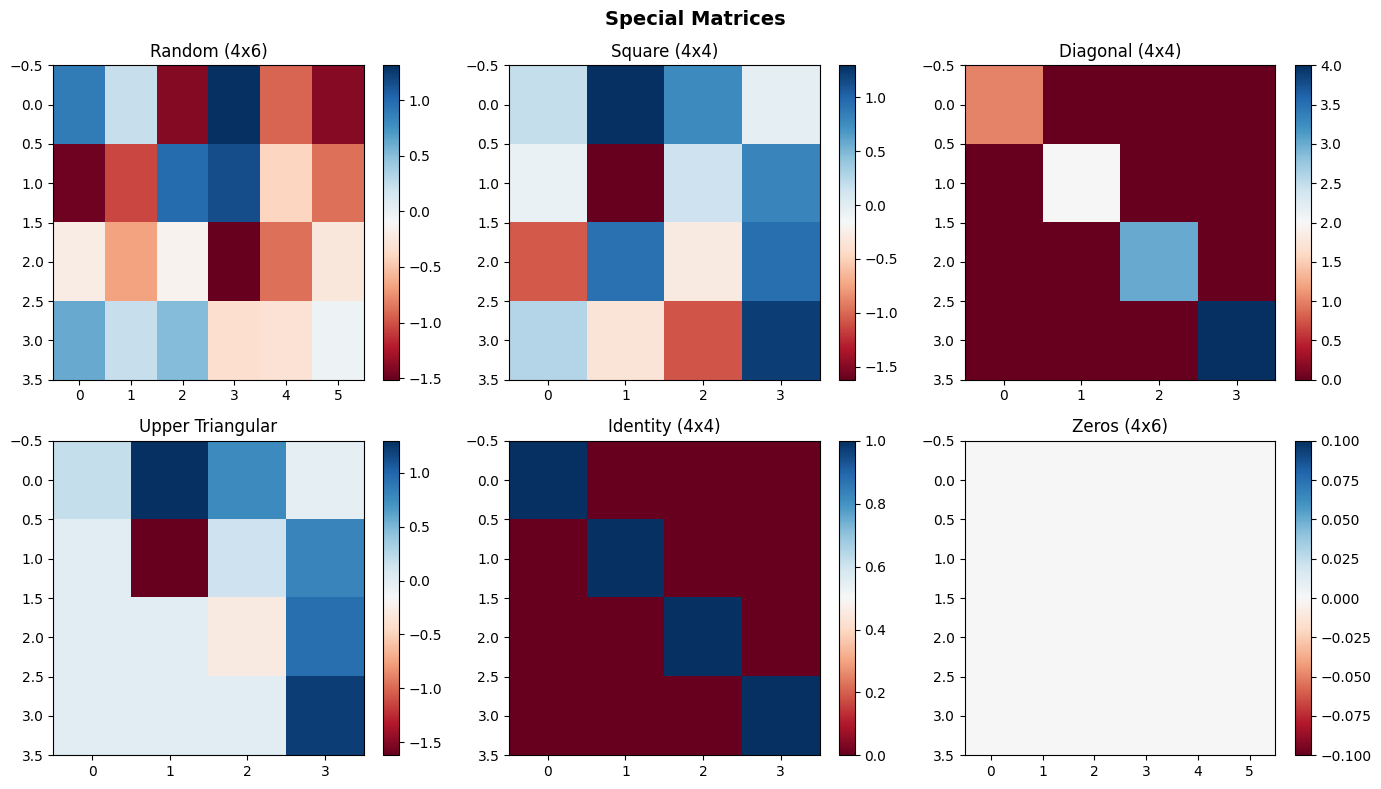

In [3]:
# Creating special matrices in NumPy
Mrows = 4
Ncols = 6

# Random numbers (Gaussian)
A_random = np.random.randn(Mrows, Ncols)

# Square matrix
A_square = np.random.randn(4, 4)

# Diagonal matrix
v = np.array([1, 2, 3, 4])
A_diag  = np.diag(v)            # vector → diagonal matrix
diag_els = np.diag(A_square)    # matrix → diagonal elements as vector

# Triangular matrices
A_upper = np.triu(A_square)     # upper triangular
A_lower = np.tril(A_square)     # lower triangular

# Identity matrix
I = np.eye(4)

# Zeros matrix
Z = np.zeros((4, 6))

# Visualize all special matrices
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
titles = ['Random (4x6)', 'Square (4x4)', 'Diagonal (4x4)',
          'Upper Triangular', 'Identity (4x4)', 'Zeros (4x6)']
matrices = [A_random, A_square, A_diag, A_upper, I, Z]

for ax, mat, title in zip(axes.flatten(), matrices, titles):
    im = ax.imshow(mat, cmap='RdBu', aspect='auto')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)

plt.suptitle('Special Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## **3. Matrix Math: Addition, Scalar Multiplication, Hadamard Multiplication**

Mathematical operations on matrices fall into two broad categories: *element-wise* operations (which are intuitive because they extend naturally from scalar arithmetic) and *structured* operations (which require more care because they involve systematic interactions between rows and columns).

### **3.1 Addition and Subtraction**

Matrix addition is defined only between matrices of identical size. Corresponding elements are simply added together — this is the most intuitive matrix operation and poses no conceptual difficulty.

### **3.2 Shifting a Matrix**

While Python allows adding a scalar directly to a matrix (broadcasting each element), this is not formally a linear algebra operation. The proper linear algebra way to add a scalar to a square matrix is called *shifting*: you add a scalar-multiplied identity matrix, expressed as `A + λI`. This changes only the diagonal elements and leaves off-diagonal elements untouched. Shifting has two particularly important applications in data science: it is the mechanism behind finding eigenvalues (Chapter 13) and behind regularizing statistical models to prevent overfitting.

### **3.3 Scalar and Hadamard Multiplications**

Scalar multiplication simply scales every element of the matrix by the same constant. Hadamard (element-wise) multiplication multiplies corresponding elements of two same-sized matrices. In NumPy, Hadamard multiplication uses the `*` operator, while standard matrix multiplication uses `@` — a subtle but critically important distinction.

In [4]:
# Matrix addition
A = np.array([[2, 3, 4], [1, 2, 4]])
B = np.array([[0, 3, 1], [-1, -4, 2]])
C = A + B
print('A ='); print(A)
print('B ='); print(B)
print('A + B ='); print(C)

A =
[[2 3 4]
 [1 2 4]]
B =
[[ 0  3  1]
 [-1 -4  2]]
A + B =
[[ 2  6  5]
 [ 0 -2  6]]


In [5]:
# Shifting a matrix: adding a scalar to the diagonal via A + λI
A = np.array([[4, 5, 1], [0, 1, 11], [4, 9, 7]])
s = 6

print('Original A:');        print(A)
print('\nA + s (broadcasting — NOT shifting):'); print(A + s)
print('\nA + s*I (proper shifting):');           print(A + s * np.eye(len(A)))
print('\nNote: only the diagonal changes!')

Original A:
[[ 4  5  1]
 [ 0  1 11]
 [ 4  9  7]]

A + s (broadcasting — NOT shifting):
[[10 11  7]
 [ 6  7 17]
 [10 15 13]]

A + s*I (proper shifting):
[[10.  5.  1.]
 [ 0.  7. 11.]
 [ 4.  9. 13.]]

Note: only the diagonal changes!


In [6]:
# Scalar and Hadamard multiplication
A = np.random.randn(3, 4)
B = np.random.randn(3, 4)
gamma = 3.0

scalar_mult   = gamma * A         # each element multiplied by gamma
hadamard_mult = A * B             # element-wise multiplication
hadamard_np   = np.multiply(A, B) # equivalent using np.multiply

print('Scalar multiplication (gamma * A):')
print(np.round(scalar_mult, 3))

print('\nHadamard multiplication (A * B):')
print(np.round(hadamard_mult, 3))

print('\nAre A*B and np.multiply(A,B) equal?', np.allclose(hadamard_mult, hadamard_np))

Scalar multiplication (gamma * A):
[[-4.714 -1.713 -0.862  5.062]
 [ 1.091  8.216  2.946 -0.812]
 [ 1.066 -2.394  0.305  3.086]]

Hadamard multiplication (A * B):
[[-0.364 -0.546  0.228  0.377]
 [ 0.119 -7.626 -0.138 -0.424]
 [ 0.498  1.022  0.016  1.1  ]]

Are A*B and np.multiply(A,B) equal? True


## **4. Standard Matrix Multiplication**

Standard matrix multiplication is the most important and most non-obvious operation in all of linear algebra. Unlike element-wise operations, matrix multiplication is **not** performed element-wise — it operates row-by-column. Specifically, the (i,j)th element of the product matrix C = AB is the dot product between the i-th row of A and the j-th column of B.

### **4.1 Rules for Matrix Multiplication Validity**

Matrix multiplication is valid **only** when the number of columns in the left matrix equals the number of rows in the right matrix. If the left matrix is M×N and the right matrix is N×K, the product is M×K. The key mnemonic: the *inner dimensions* must match; the *outer dimensions* define the product size.

This rule immediately reveals that matrix multiplication is **not commutative**: AB may be valid while BA is invalid. Even when both are valid (e.g., both are square), they generally produce different results.

### **4.2 Matrix-Vector Multiplication**

Matrix-vector multiplication is a special case of matrix multiplication. It has several profound interpretations. One is that it computes **linear weighted combinations**: a matrix A whose columns are vectors, multiplied by a coefficient vector v, produces the linear combination of A's columns weighted by the elements of v. Another is **geometric transformation**: a matrix can rotate and stretch a vector (or a set of coordinates), making matrix-vector multiplication the mathematical engine behind computer graphics, signal processing, and PCA.

In [7]:
# Demonstrating matrix multiplication validity
A = np.random.randn(3, 4)  # 3x4
B = np.random.randn(4, 5)  # 4x5
C = A @ B                  # valid: 3x4 @ 4x5 = 3x5

print(f'A shape: {A.shape}')
print(f'B shape: {B.shape}')
print(f'C = A @ B shape: {C.shape}')
print(f'\nInner dimensions match: {A.shape[1]} == {B.shape[0]} → {A.shape[1] == B.shape[0]}')
print(f'Product dimensions: {A.shape[0]} x {B.shape[1]}')

# Try invalid multiplication
try:
    D = B @ A  # invalid: 4x5 @ 3x4
except ValueError as e:
    print(f'\nB @ A fails: {e}')

A shape: (3, 4)
B shape: (4, 5)
C = A @ B shape: (3, 5)

Inner dimensions match: 4 == 4 → True
Product dimensions: 3 x 5

B @ A fails: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 3 is different from 5)


In [8]:
# Manual matrix multiplication using for loops (to understand the mechanics)
A = np.array([[2, 3], [4, 5]])
B = np.array([['a', 'b'], ['c', 'd']])

# Show example from book: (2,3;4,5) @ (a,b;c,d)
print('Numerical example:')
A_num = np.array([[2, 3], [4, 5]])
B_num = np.array([[1, 2], [3, 4]])
print(f'A = \n{A_num}')
print(f'B = \n{B_num}')
print(f'A @ B = \n{A_num @ B_num}')
print('\nC[0,0] = 2*1 + 3*3 =', 2*1 + 3*3, '(dot product of row 0 of A with col 0 of B)')
print('C[0,1] = 2*2 + 3*4 =', 2*2 + 3*4, '(dot product of row 0 of A with col 1 of B)')

Numerical example:
A = 
[[2 3]
 [4 5]]
B = 
[[1 2]
 [3 4]]
A @ B = 
[[11 16]
 [19 28]]

C[0,0] = 2*1 + 3*3 = 11 (dot product of row 0 of A with col 0 of B)
C[0,1] = 2*2 + 3*4 = 16 (dot product of row 0 of A with col 1 of B)


In [9]:
# Matrix-vector multiplication as linear weighted combination
# Vectors as columns of a matrix, weights as vector elements
M = np.array([[3, 1],
              [0, 2],
              [6, 5]])  # matrix with two column vectors

weights = np.array([4, 3])  # weight vector

# Method 1: explicit linear combination
combo_explicit = weights[0] * M[:, 0] + weights[1] * M[:, 1]

# Method 2: matrix-vector multiplication
combo_matmul = M @ weights

print('Linear combination (explicit):', combo_explicit)
print('Matrix-vector product M @ w:  ', combo_matmul)
print('Are they equal?', np.allclose(combo_explicit, combo_matmul))

Linear combination (explicit): [15  6 39]
Matrix-vector product M @ w:   [15  6 39]
Are they equal? True


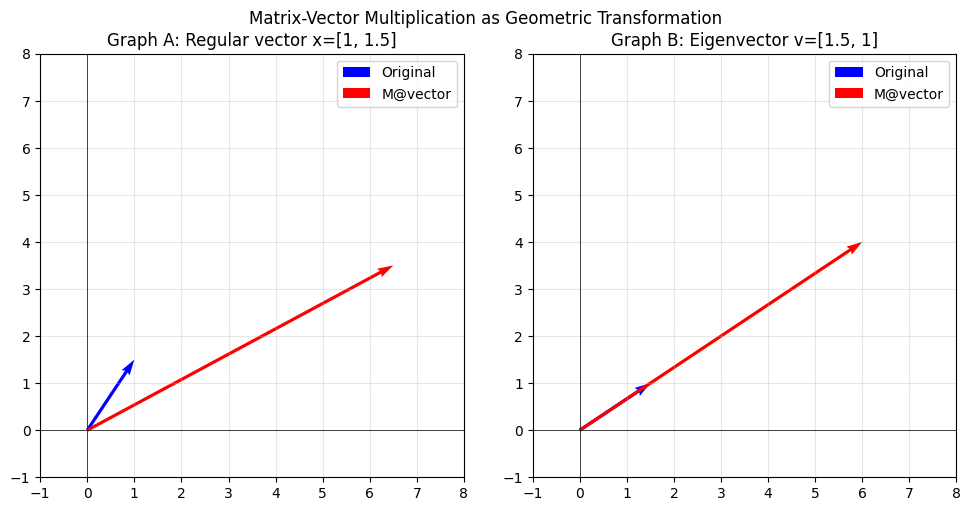

Note: In Graph B, the direction of v is preserved — v is an eigenvector of M!


In [10]:
# Geometric transformation via matrix-vector multiplication
M  = np.array([[2, 3], [2, 1]])
x  = np.array([[1, 1.5]]).T   # column vector
v  = np.array([[1.5, 1]]).T   # swapped elements
Mx = M @ x
Mv = M @ v

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, orig, transformed, title in zip(
    axes,
    [x, v],
    [Mx, Mv],
    ['Graph A: Regular vector x=[1, 1.5]', 'Graph B: Eigenvector v=[1.5, 1]']
):
    ax.quiver(0, 0, orig[0,0], orig[1,0],
              angles='xy', scale_units='xy', scale=1, color='blue', label='Original')
    ax.quiver(0, 0, transformed[0,0], transformed[1,0],
              angles='xy', scale_units='xy', scale=1, color='red', label='M@vector')
    ax.set_xlim(-1, 8); ax.set_ylim(-1, 8)
    ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
    ax.grid(True, alpha=0.3); ax.set_aspect('equal')
    ax.legend(); ax.set_title(title)

plt.suptitle('Matrix-Vector Multiplication as Geometric Transformation', fontsize=12)
plt.tight_layout()
plt.show()
print('Note: In Graph B, the direction of v is preserved — v is an eigenvector of M!')

## **5. Matrix Operations: Transpose**

The transpose operation swaps the rows and columns of a matrix. Formally, the (i,j)th element of A becomes the (j,i)th element of Aᵀ. Double-transposing recovers the original matrix: (Aᵀ)ᵀ = A.

### **5.1 Dot and Outer Product Notation**

The transpose makes the notation of the dot product precise. Two column vectors, each M×1, have sizes 1×M and M×1 when the first is transposed. Their "inner" dimensions match, and the "outer" dimensions (1×1) tell us the product is a scalar — which is why the dot product is written as **aᵀb**. The outer product reverses this: a column M×1 times a row 1×N gives an M×N matrix.

### **5.2 LIVE EVIL (Order of Operations)**

A crucial rule for transposing products of matrices: **(LIVE)ᵀ = Eᵀ Vᵀ Iᵀ Lᵀ**. The transpose of a product of matrices equals the product of the individually transposed matrices, but in **reversed order**. This rule is not arbitrary — it is the only way to make the sizes work out correctly.

In [11]:
# Transpose demonstration
A = np.array([[3, 4, 5], [1, 2, 3]])
print('A:');  print(A)
print('\nA.T (method):');        print(A.T)
print('\nnp.transpose(A) (function):'); print(np.transpose(A))
print('\nAre they equal?', np.allclose(A.T, np.transpose(A)))

# What happens when transposing a 1D array?
v_1d = np.array([1, 2, 3])
print('\n1D array:', v_1d, '| shape:', v_1d.shape)
print('1D array transposed:', v_1d.T, '| shape:', v_1d.T.shape)
print('→ Transposing a 1D array does nothing! Use reshape to make a proper column vector.')

A:
[[3 4 5]
 [1 2 3]]

A.T (method):
[[3 1]
 [4 2]
 [5 3]]

np.transpose(A) (function):
[[3 1]
 [4 2]
 [5 3]]

Are they equal? True

1D array: [1 2 3] | shape: (3,)
1D array transposed: [1 2 3] | shape: (3,)
→ Transposing a 1D array does nothing! Use reshape to make a proper column vector.


In [12]:
# LIVE EVIL rule: (LIVE)^T = E^T V^T I^T L^T
L = np.random.randn(2, 6)
I = np.random.randn(6, 3)
V = np.random.randn(3, 5)
E = np.random.randn(5, 2)

# Step 1: Multiply and transpose the product
LIVE_T = (L @ I @ V @ E).T

# Step 2: Transpose individually AND reverse order (LIVE EVIL rule)
EVIL_correct = E.T @ V.T @ I.T @ L.T

print('(LIVE)^T vs E^T V^T I^T L^T (LIVE EVIL rule):')
print('  Are they equal?', np.allclose(LIVE_T, EVIL_correct))

(LIVE)^T vs E^T V^T I^T L^T (LIVE EVIL rule):
  Are they equal? True


## **6. Symmetric Matrices**

A symmetric matrix is one where each row equals its corresponding column — which is equivalent to saying the matrix equals its own transpose: **A = Aᵀ**. Symmetric matrices must be square (a nonsquare matrix and its transpose are different sizes and cannot be equal). They have many special properties that make them numerically well-behaved and analytically tractable: they always have real eigenvalues, orthogonal eigenvectors, and they arise naturally in statistics (covariance matrices, correlation matrices, Gram matrices).

### **6.1 Creating Symmetric Matrices from Nonsymmetric Matrices**

A beautiful and fundamental result: multiplying **any** matrix — even a rectangular, nonsymmetric one — by its own transpose yields a square symmetric matrix. Both AᵀA and AAᵀ are symmetric (though they are different matrices in general, and if A is rectangular, not even the same size). The proof uses the LIVE EVIL rule:

$$(A^T A)^T = A^T (A^T)^T = A^T A$$

This multiplicative method for creating symmetric matrices is central to statistics (covariance matrices are computed this way) and to the singular value decomposition.

In [13]:
# Check if a matrix is symmetric
def is_symmetric(A, tol=1e-10):
    """Return True if matrix A is symmetric (within numerical tolerance)."""
    if A.shape[0] != A.shape[1]:
        return False
    return np.allclose(A, A.T, atol=tol)

# Test on a known symmetric matrix
S = np.array([[1, 2, 3],
              [2, 5, 6],
              [3, 6, 9]])
print('Symmetric matrix S:')
print(S)
print('Is symmetric?', is_symmetric(S))

# Test on a nonsymmetric matrix
N = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]])
print('\nNonsymmetric matrix N:')
print(N)
print('Is symmetric?', is_symmetric(N))

Symmetric matrix S:
[[1 2 3]
 [2 5 6]
 [3 6 9]]
Is symmetric? True

Nonsymmetric matrix N:
[[1 2 3]
 [4 5 6]
 [7 8 9]]
Is symmetric? False


A shape: (5, 3)
A^T A shape: (3, 3) — symmetric? True
A A^T shape: (5, 5) — symmetric? True

Additive method (B + B^T)/2 — symmetric? True


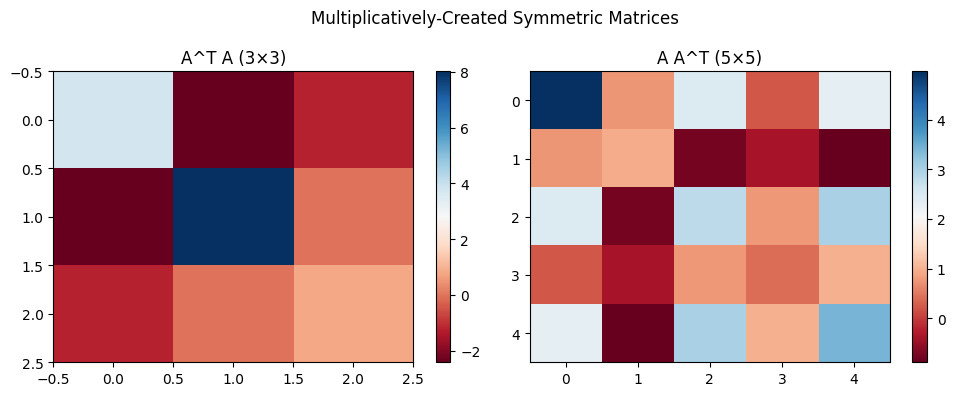

In [14]:
# Multiplicative method: A^T A and A A^T are always symmetric
A = np.random.randn(5, 3)  # tall nonsquare matrix

AtA = A.T @ A   # 3x3 symmetric
AAt = A @ A.T   # 5x5 symmetric

print(f'A shape: {A.shape}')
print(f'A^T A shape: {AtA.shape} — symmetric? {is_symmetric(AtA)}')
print(f'A A^T shape: {AAt.shape} — symmetric? {is_symmetric(AAt)}')

# Additive method: (A + A^T) / 2 is symmetric for square A
B = np.random.randn(4, 4)  # square nonsymmetric matrix
B_sym = (B + B.T) / 2
print(f'\nAdditive method (B + B^T)/2 — symmetric? {is_symmetric(B_sym)}')

# Visualize AtA and AAt
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, mat, title in zip(axes, [AtA, AAt], ['A^T A (3×3)', 'A A^T (5×5)']):
    im = ax.imshow(mat, cmap='RdBu', aspect='auto')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
plt.suptitle('Multiplicatively-Created Symmetric Matrices', fontsize=12)
plt.tight_layout()
plt.show()

## **8. Summary**

Chapter 5 establishes the foundational layer from which all matrix operations are built. The key insights developed in this chapter are:

- Matrices are, at their core, spreadsheets of numbers — but they can be conceptualized as collections of column vectors, row vectors, or individual scalar elements depending on context. Visualizing them as pseudocolored images is often the most practical approach for large matrices.

- There are several important families of special matrices (random, square, diagonal, triangular, identity, zeros). Familiarity with these families is essential because they appear constantly in linear algebra operations and often admit computational shortcuts.

- Element-wise operations (addition, scalar multiplication, Hadamard multiplication) are straightforward extensions of scalar arithmetic. Shifting — adding a scalar-multiplied identity to a square matrix — is the linear-algebra-correct way to modify only the diagonal, and it underlies both eigenvalue finding and model regularization.

- Standard matrix multiplication is **not** element-wise: the (i,j)th element of the product is the dot product of row i of the left matrix with column j of the right matrix. The validity rule M×N times N×K = M×K is worth memorizing as a picture. Matrix-vector multiplication is a special case that can be interpreted as computing linear weighted combinations or applying geometric transformations.

- The LIVE EVIL rule governs how transposes distribute across products: **(LIVE)ᵀ = Eᵀ Vᵀ Iᵀ Lᵀ**.

- Symmetric matrices (A = Aᵀ) arise naturally in statistics and optimization. Any matrix A, regardless of shape, produces a symmetric matrix via AᵀA or AAᵀ — a fact central to covariance matrices and the SVD.